# Análise Exploratória de Dados — E-commerce Olist

## Contexto e objetivo

Este notebook apresenta a exploração inicial da base pública de comércio eletrônico da Olist. O objetivo é conhecer a estrutura dos dados, verificar sua qualidade e preparar as informações para análises de vendas, clientes, produtos, pagamentos e entregas.

**Fonte dos dados:** Brazilian E-Commerce Public Dataset by Olist, disponível no Kaggle.

**Objetivo desta etapa:** carregar as tabelas, identificar suas dimensões, conhecer as colunas e verificar valores ausentes e registros duplicados.


## 1. Configuração e importação das bibliotecas

Nesta etapa, importaremos as bibliotecas necessárias e definiremos o caminho da pasta que contém os dados brutos.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
CAMINHO_DADOS = Path("../data/raw")

arquivos_csv = sorted(CAMINHO_DADOS.glob("*.csv"))

print(f"Quantidade de arquivos encontrados: {len(arquivos_csv)}")

for arquivo in arquivos_csv:
    print("-", arquivo.name)

Quantidade de arquivos encontrados: 9
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv


## 2. Carregamento das tabelas

Os arquivos CSV serão carregados em DataFrames do Pandas. Cada DataFrame representa uma tabela do conjunto de dados da Olist.

### 2.1 Leitura dos arquivos CSV

In [4]:
clientes = pd.read_csv(CAMINHO_DADOS / "olist_customers_dataset.csv")
geolocalizacao = pd.read_csv(CAMINHO_DADOS / "olist_geolocation_dataset.csv")
itens_pedido = pd.read_csv(CAMINHO_DADOS / "olist_order_items_dataset.csv")
pagamentos = pd.read_csv(CAMINHO_DADOS / "olist_order_payments_dataset.csv")
avaliacoes = pd.read_csv(CAMINHO_DADOS / "olist_order_reviews_dataset.csv")
pedidos = pd.read_csv(CAMINHO_DADOS / "olist_orders_dataset.csv")
produtos = pd.read_csv(CAMINHO_DADOS / "olist_products_dataset.csv")
vendedores = pd.read_csv(CAMINHO_DADOS / "olist_sellers_dataset.csv")
categorias_traducao = pd.read_csv(
    CAMINHO_DADOS / "product_category_name_translation.csv"
)

print("As nove tabelas foram carregadas com sucesso!")

As nove tabelas foram carregadas com sucesso!


### 2.2 Dimensões das tabelas

A dimensão de uma tabela informa sua quantidade de linhas e colunas. Essa verificação ajuda a compreender o tamanho e a estrutura de cada conjunto de dados.

In [5]:
tabelas = {
    "clientes": clientes,
    "geolocalizacao": geolocalizacao,
    "itens_pedido": itens_pedido,
    "pagamentos": pagamentos,
    "avaliacoes": avaliacoes,
    "pedidos": pedidos,
    "produtos": produtos,
    "vendedores": vendedores,
    "categorias_traducao": categorias_traducao,
}

resumo_dimensoes = pd.DataFrame(
    [
        {
            "tabela": nome,
            "linhas": dataframe.shape[0],
            "colunas": dataframe.shape[1],
        }
        for nome, dataframe in tabelas.items()
    ]
).sort_values("linhas", ascending=False).reset_index(drop=True)

resumo_dimensoes

,tabela,linhas,colunas
0,geolocalizacao,1000163,5
1,itens_pedido,112650,7
2,pagamentos,103886,5
3,clientes,99441,5
4,pedidos,99441,8
5,avaliacoes,99224,7
6,produtos,32951,9
7,vendedores,3095,4
8,categorias_traducao,71,2


**Interpretação inicial:** a tabela de geolocalização é a maior base do conjunto de dados. As tabelas de itens e pagamentos possuem mais registros que a tabela de pedidos, indicando que um mesmo pedido pode estar relacionado a vários produtos ou registros de pagamento. Essas relações serão verificadas nas próximas etapas.

## 3. Conhecendo a tabela de pedidos

A tabela de pedidos será examinada inicialmente porque conecta clientes, pagamentos, avaliações e itens vendidos.

In [6]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


**Interpretação:** a tabela de pedidos possui 99.441 registros e 8 colunas. As colunas de data foram inicialmente carregadas como texto e precisarão ser convertidas. Também foram identificados valores ausentes nas datas de aprovação e entrega. Antes de tratar esses valores, será necessário verificar sua relação com a situação de cada pedido.

### 3.1 Verificação de valores ausentes

A quantidade e o percentual de valores ausentes serão calculados para cada coluna da tabela de pedidos.

In [8]:
quantidade_ausentes = pedidos.isna().sum()

percentual_ausentes = (
    quantidade_ausentes / len(pedidos) * 100
).round(2)

resumo_ausentes = pd.DataFrame(
    {
        "quantidade_ausentes": quantidade_ausentes,
        "percentual_ausentes": percentual_ausentes,
    }
)

resumo_ausentes = resumo_ausentes[
    resumo_ausentes["quantidade_ausentes"] > 0
].sort_values("quantidade_ausentes", ascending=False)

resumo_ausentes

,quantidade_ausentes,percentual_ausentes
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


**Resultado inicial:** a maior proporção de valores ausentes está na data de entrega ao cliente, correspondendo a 2,98% dos pedidos. Esses registros não serão removidos antes de verificarmos se a ausência está associada a pedidos cancelados, indisponíveis ou ainda não entregues.

### 3.2 Relação entre ausência da entrega e situação do pedido

Será analisada a situação dos pedidos que não possuem uma data de entrega ao cliente.

In [9]:
status_sem_entrega = (
    pedidos.loc[
        pedidos["order_delivered_customer_date"].isna(),
        "order_status",
    ]
    .value_counts()
    .rename_axis("situacao_pedido")
    .reset_index(name="quantidade")
)

status_sem_entrega["percentual"] = (
    status_sem_entrega["quantidade"]
    / status_sem_entrega["quantidade"].sum()
    * 100
).round(2)

status_sem_entrega

,situacao_pedido,quantidade,percentual
0,shipped,1107,37.34
1,canceled,619,20.88
2,unavailable,609,20.54
3,invoiced,314,10.59
4,processing,301,10.15
5,delivered,8,0.27
6,created,5,0.17
7,approved,2,0.07


**Interpretação:** a ausência da data de entrega está majoritariamente associada a pedidos que ainda estavam em processamento, haviam sido enviados, foram cancelados ou ficaram indisponíveis. Portanto, a maior parte dos valores ausentes possui uma explicação relacionada ao processo do pedido e não deve ser tratada automaticamente como erro.

Foram encontrados apenas 8 pedidos classificados como entregues sem a respectiva data de entrega. Esses casos representam uma possível inconsistência de qualidade dos dados e deverão ser analisados separadamente.

### 3.3 Verificação de registros duplicados

A próxima análise verificará se existem linhas completamente duplicadas ou identificadores de pedidos repetidos.

In [10]:
linhas_duplicadas = pedidos.duplicated().sum()
ids_pedido_duplicados = pedidos["order_id"].duplicated().sum()

resumo_duplicados = pd.DataFrame(
    {
        "verificacao": [
            "Linhas completamente duplicadas",
            "Identificadores de pedido duplicados",
        ],
        "quantidade": [
            linhas_duplicadas,
            ids_pedido_duplicados,
        ],
    }
)

resumo_duplicados

,verificacao,quantidade
0,Linhas completamente duplicadas,0
1,Identificadores de pedido duplicados,0


**Resultado:** não foram encontrados registros completamente duplicados nem identificadores de pedido repetidos. Isso confirma que cada linha representa um pedido distinto e que `order_id` pode ser utilizado como chave única da tabela.

## 4. Preparação dos dados

### 4.1 Conversão das colunas de data

As datas foram carregadas originalmente como texto. Elas serão convertidas para o tipo `datetime`, permitindo calcular períodos, prazos de entrega e evolução temporal das vendas.

In [11]:
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for coluna in colunas_data:
    pedidos[coluna] = pd.to_datetime(
        pedidos[coluna],
        errors="coerce",
    )

pedidos[colunas_data].dtypes.to_frame(name="tipo_de_dado")

,tipo_de_dado
order_purchase_timestamp,datetime64[us]
order_approved_at,datetime64[us]
order_delivered_carrier_date,datetime64[us]
order_delivered_customer_date,datetime64[us]
order_estimated_delivery_date,datetime64[us]


**Resultado:** as cinco colunas temporais foram convertidas com sucesso para o tipo `datetime`. A partir dessa conversão, será possível calcular o tempo de entrega, comparar a entrega real com a estimativa e analisar a evolução dos pedidos ao longo do tempo.


## 5. Indicadores iniciais de pedidos

### 5.1 Período analisado e situação dos pedidos

Nesta etapa serão calculados o período coberto pela base, o total de pedidos e a distribuição dos pedidos por situação.

In [12]:
data_inicial = pedidos["order_purchase_timestamp"].min()
data_final = pedidos["order_purchase_timestamp"].max()

total_pedidos = pedidos["order_id"].nunique()
pedidos_entregues = (
    pedidos["order_status"] == "delivered"
).sum()

taxa_entrega = (
    pedidos_entregues / total_pedidos * 100
)

indicadores_pedidos = pd.DataFrame(
    {
        "indicador": [
            "Data inicial",
            "Data final",
            "Total de pedidos",
            "Pedidos entregues",
            "Taxa de entrega",
        ],
        "valor": [
            data_inicial.strftime("%d/%m/%Y"),
            data_final.strftime("%d/%m/%Y"),
            total_pedidos,
            pedidos_entregues,
            f"{taxa_entrega:.2f}%",
        ],
    }
)

indicadores_pedidos

,indicador,valor
0,Data inicial,04/09/2016
1,Data final,17/10/2018
2,Total de pedidos,99441
3,Pedidos entregues,96478
4,Taxa de entrega,97.02%


**Resultado:** a base cobre o período de 04/09/2016 a 17/10/2018 e contém 99.441 pedidos. Desses, 96.478 foram entregues, resultando em uma taxa de entrega de 97,02%.

Os meses de setembro de 2016 e outubro de 2018 possuem cobertura parcial. Por isso, comparações mensais futuras deverão considerar que esses períodos não representam meses completos.

### 5.2 Distribuição dos pedidos por situação

A distribuição por situação permitirá visualizar a quantidade de pedidos entregues, cancelados e presentes nas demais etapas do processo.

In [13]:
traducao_status = {
    "delivered": "Entregue",
    "shipped": "Enviado",
    "canceled": "Cancelado",
    "unavailable": "Indisponível",
    "invoiced": "Faturado",
    "processing": "Em processamento",
    "created": "Criado",
    "approved": "Aprovado",
}

distribuicao_status = (
    pedidos["order_status"]
    .value_counts()
    .rename_axis("status_original")
    .reset_index(name="quantidade")
)

distribuicao_status["situacao"] = (
    distribuicao_status["status_original"]
    .map(traducao_status)
)

distribuicao_status["percentual"] = (
    distribuicao_status["quantidade"]
    / distribuicao_status["quantidade"].sum()
    * 100
).round(2)

distribuicao_status[
    ["situacao", "quantidade", "percentual"]
]

,situacao,quantidade,percentual
0,Entregue,96478,97.02
1,Enviado,1107,1.11
2,Cancelado,625,0.63
3,Indisponível,609,0.61
4,Faturado,314,0.32
5,Em processamento,301,0.30
6,Criado,5,0.01
7,Aprovado,2,0.00


### 5.3 Pedidos não entregues por situação

Como os pedidos entregues representam 97,02% do total, o gráfico a seguir apresenta apenas as demais situações. Assim, é possível comparar melhor as exceções do processo de entrega.

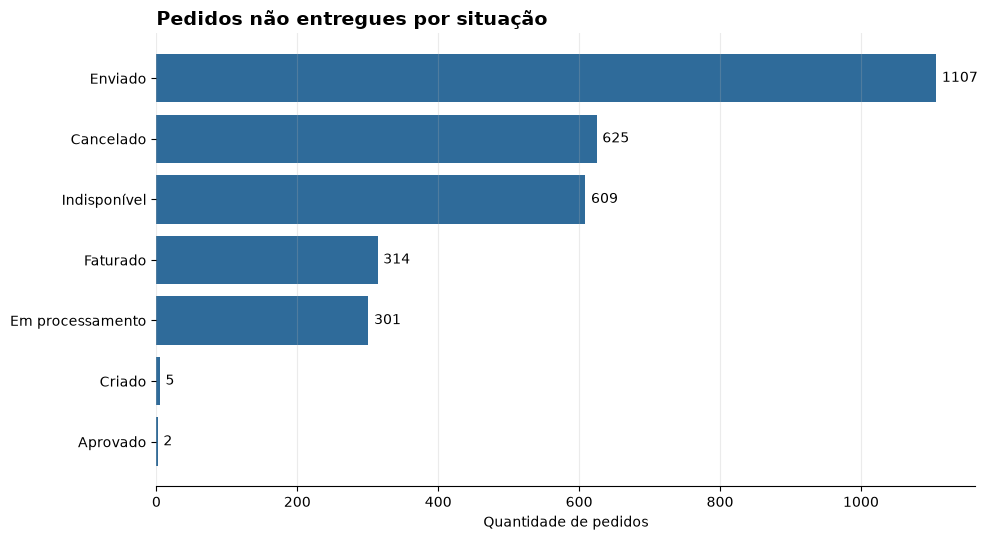

In [14]:
status_nao_entregues = (
    distribuicao_status
    .loc[distribuicao_status["status_original"] != "delivered"]
    .sort_values("quantidade", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

barras = ax.barh(
    status_nao_entregues["situacao"],
    status_nao_entregues["quantidade"],
    color="#2F6B9A"
)

ax.bar_label(barras, padding=4)

ax.set_title(
    "Pedidos não entregues por situação",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Quantidade de pedidos")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

Nesta etapa, será analisada a evolução mensal do volume de pedidos. Para evitar comparações distorcidas por períodos com cobertura parcial, o gráfico considera os dados de outubro de 2016 a agosto de 2018. Novembro de 2016 foi mantido com zero pedidos registrados para preservar a continuidade temporal.

In [16]:
pedidos_mensais = (
    pedidos
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .size()
    .rename("quantidade_pedidos")
    .reset_index()
    .rename(columns={"order_purchase_timestamp": "mes"})
)

pedidos_mensais_completos = (
    pedidos_mensais[
        (pedidos_mensais["mes"] > pedidos_mensais["mes"].min())
        & (pedidos_mensais["mes"] < pedidos_mensais["mes"].max())
    ]
    .reset_index(drop=True)
)

pedidos_mensais_completos

,mes,quantidade_pedidos
0,2016-10-01,324
1,2016-11-01,0
2,2016-12-01,1
3,2017-01-01,800
4,2017-02-01,1780
5,2017-03-01,2682
6,2017-04-01,2404
7,2017-05-01,3700
8,2017-06-01,3245
9,2017-07-01,4026


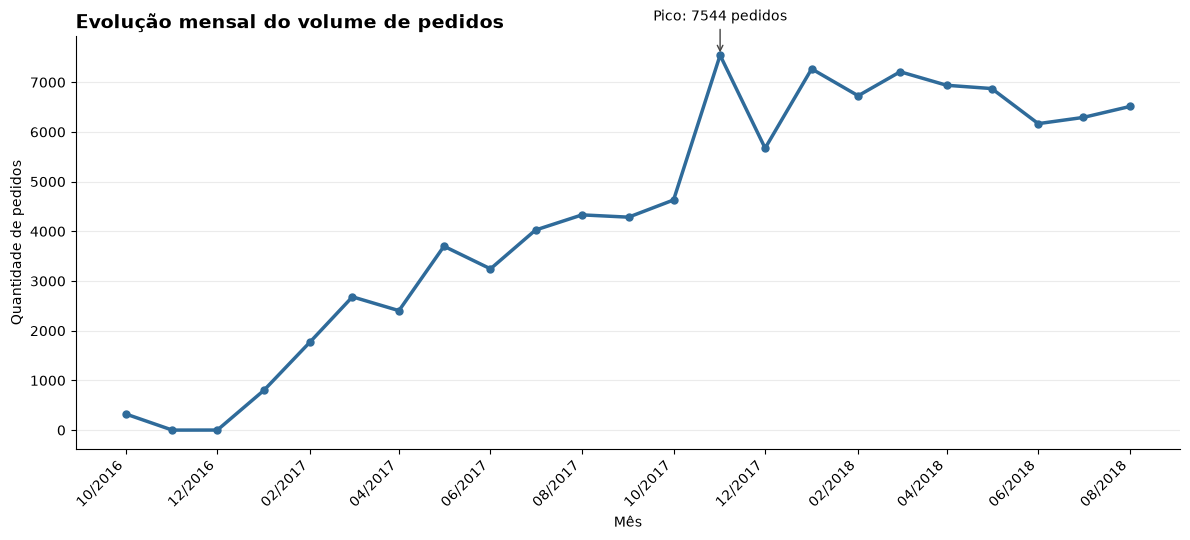

In [20]:
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    pedidos_mensais_completos["mes"],
    pedidos_mensais_completos["quantidade_pedidos"],
    color="#2F6B9A",
    linewidth=2.5,
    marker="o",
    markersize=5
)

pico = pedidos_mensais_completos.loc[
    pedidos_mensais_completos["quantidade_pedidos"].idxmax()
]

ax.annotate(
    f'Pico: {pico["quantidade_pedidos"]} pedidos',
    xy=(pico["mes"], pico["quantidade_pedidos"]),
    xytext=(0, 25),
    textcoords="offset points",
    ha="center",
    arrowprops={"arrowstyle": "->", "color": "#444444"}
)

indices_rotulos = list(range(0, len(pedidos_mensais_completos), 2))

if len(pedidos_mensais_completos) - 1 not in indices_rotulos:
    indices_rotulos.append(len(pedidos_mensais_completos) - 1)

datas_rotulos = pedidos_mensais_completos.loc[indices_rotulos, "mes"]

ax.set_xticks(datas_rotulos)
ax.set_xticklabels(
    datas_rotulos.dt.strftime("%m/%Y"),
    rotation=45,
    ha="right"
)

ax.set_title(
    "Evolução mensal do volume de pedidos",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Mês")
ax.set_ylabel("Quantidade de pedidos")
ax.grid(axis="y", alpha=0.25)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Evolução dos pedidos ao longo do tempo

### 6.1 Quantidade mensal de pedidos

#### Interpretação

O volume de pedidos apresentou forte crescimento ao longo de 2017, atingindo o pico de 7.544 pedidos em novembro daquele ano. Esse resultado pode estar relacionado ao período promocional da Black Friday, mas essa hipótese precisa ser investigada com análises adicionais.

Durante 2018, o volume mensal permaneceu relativamente estável, geralmente entre aproximadamente 6 mil e 7,2 mil pedidos. Os poucos registros de 2016 indicam uma fase inicial da operação ou uma cobertura ainda limitada da base, por isso esse período deve ser interpretado com cautela.

## 7. Desempenho das entregas

### 7.1 Tempo de entrega e cumprimento do prazo estimado

Nesta etapa, serão considerados apenas os pedidos entregues que possuem as datas necessárias. Serão calculados o tempo decorrido entre a compra e a entrega e o percentual de pedidos entregues dentro do prazo estimado.

In [21]:
pedidos_entregues = pedidos[
    (pedidos["order_status"] == "delivered")
    & pedidos["order_purchase_timestamp"].notna()
    & pedidos["order_delivered_customer_date"].notna()
    & pedidos["order_estimated_delivery_date"].notna()
].copy()

pedidos_entregues["tempo_entrega_dias"] = (
    pedidos_entregues["order_delivered_customer_date"]
    - pedidos_entregues["order_purchase_timestamp"]
).dt.total_seconds() / 86400

pedidos_entregues["atraso_dias"] = (
    pedidos_entregues["order_delivered_customer_date"]
    - pedidos_entregues["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

pedidos_entregues["entregue_no_prazo"] = (
    pedidos_entregues["order_delivered_customer_date"]
    <= pedidos_entregues["order_estimated_delivery_date"]
)

resumo_entregas = pd.DataFrame(
    {
        "indicador": [
            "Pedidos analisados",
            "Tempo médio de entrega",
            "Tempo mediano de entrega",
            "Pedidos entregues no prazo",
        ],
        "valor": [
            len(pedidos_entregues),
            f'{pedidos_entregues["tempo_entrega_dias"].mean():.2f} dias',
            f'{pedidos_entregues["tempo_entrega_dias"].median():.2f} dias',
            f'{pedidos_entregues["entregue_no_prazo"].mean() * 100:.2f}%',
        ],
    }
)

resumo_entregas

,indicador,valor
0,Pedidos analisados,96470
1,Tempo médio de entrega,12.56 dias
2,Tempo mediano de entrega,10.22 dias
3,Pedidos entregues no prazo,91.89%


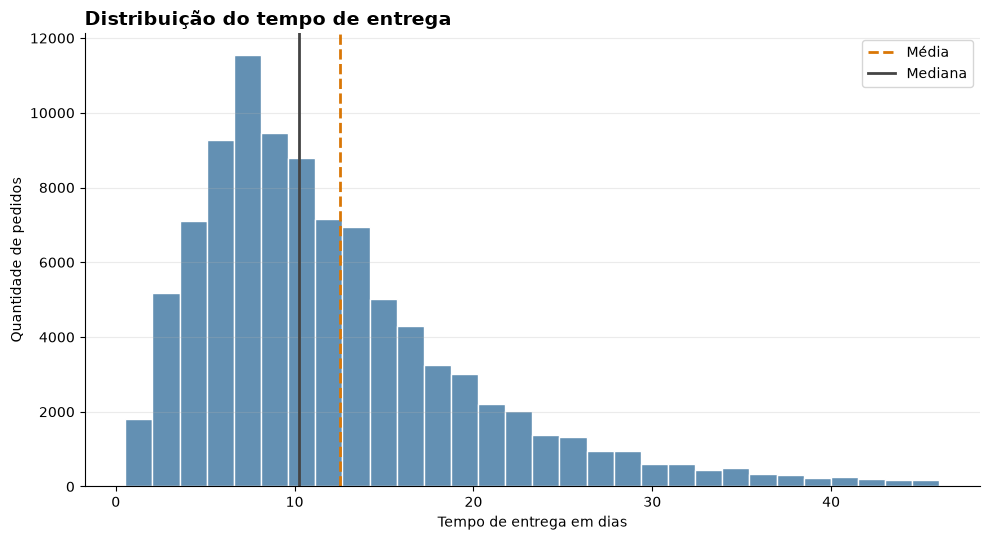

In [22]:
limite_visual = pedidos_entregues["tempo_entrega_dias"].quantile(0.99)

tempos_para_grafico = pedidos_entregues[
    pedidos_entregues["tempo_entrega_dias"] <= limite_visual
]

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.histplot(
    data=tempos_para_grafico,
    x="tempo_entrega_dias",
    bins=30,
    color="#2F6B9A",
    edgecolor="white",
    ax=ax
)

ax.axvline(
    pedidos_entregues["tempo_entrega_dias"].mean(),
    color="#D97706",
    linestyle="--",
    linewidth=2,
    label="Média"
)

ax.axvline(
    pedidos_entregues["tempo_entrega_dias"].median(),
    color="#444444",
    linestyle="-",
    linewidth=2,
    label="Mediana"
)

ax.set_title(
    "Distribuição do tempo de entrega",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Tempo de entrega em dias")
ax.set_ylabel("Quantidade de pedidos")
ax.legend()
ax.grid(axis="y", alpha=0.25)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretação

A maior concentração de entregas ocorre aproximadamente entre 5 e 15 dias. O tempo mediano foi de 10,22 dias, enquanto a média foi de 12,56 dias. A média maior que a mediana indica que os pedidos com entregas muito demoradas elevam o valor médio.

Além disso, 91,89% dos pedidos foram entregues dentro da data estimada. Para melhorar a leitura, o gráfico apresenta até o percentil 99 dos tempos de entrega, mas os indicadores foram calculados utilizando todos os 96.470 pedidos analisados.

### 7.2 Desempenho das entregas por estado

Nesta etapa, os pedidos entregues serão associados ao estado do cliente. O objetivo é comparar o tempo mediano de entrega e a taxa de cumprimento do prazo entre as unidades federativas.

In [23]:
entregas_por_estado = pedidos_entregues.merge(
    clientes[["customer_id", "customer_state"]],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

resumo_entregas_estado = (
    entregas_por_estado
    .groupby("customer_state")
    .agg(
        quantidade_pedidos=("order_id", "count"),
        tempo_mediano_dias=("tempo_entrega_dias", "median"),
        taxa_no_prazo=("entregue_no_prazo", "mean")
    )
    .reset_index()
)

resumo_entregas_estado["tempo_mediano_dias"] = (
    resumo_entregas_estado["tempo_mediano_dias"].round(2)
)

resumo_entregas_estado["taxa_no_prazo"] = (
    resumo_entregas_estado["taxa_no_prazo"] * 100
).round(2)

resumo_entregas_estado = resumo_entregas_estado.sort_values(
    "tempo_mediano_dias",
    ascending=False
).reset_index(drop=True)

resumo_entregas_estado

,customer_state,quantidade_pedidos,tempo_mediano_dias,taxa_no_prazo
0,AM,145,25.88,95.86
1,RR,41,25.01,87.80
2,AP,67,24.35,95.52
3,AL,397,22.33,76.07
4,PA,946,21.08,87.63
5,MA,717,19.19,80.33
6,AC,80,18.36,96.25
7,CE,1279,18.21,84.68
8,PB,517,18.15,88.97
9,SE,335,18.01,84.78


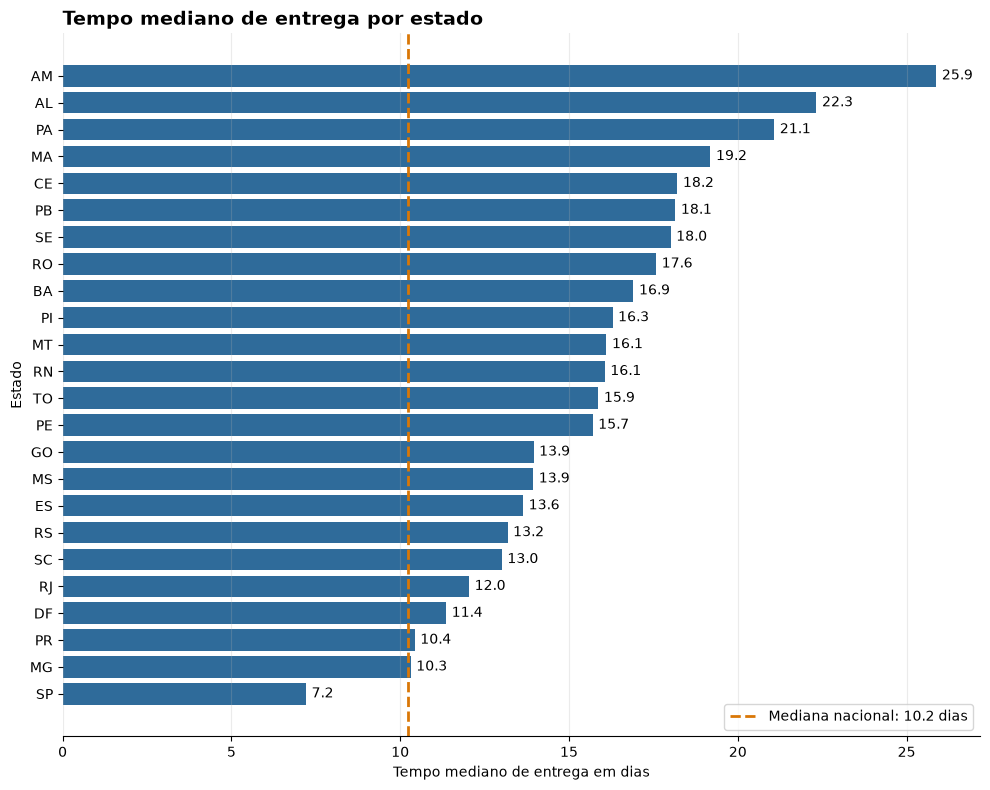

In [24]:
estados_para_grafico = (
    resumo_entregas_estado[
        resumo_entregas_estado["quantidade_pedidos"] >= 100
    ]
    .sort_values("tempo_mediano_dias", ascending=True)
)

mediana_nacional = pedidos_entregues["tempo_entrega_dias"].median()

fig, ax = plt.subplots(figsize=(10, 8))

barras = ax.barh(
    estados_para_grafico["customer_state"],
    estados_para_grafico["tempo_mediano_dias"],
    color="#2F6B9A"
)

ax.bar_label(
    barras,
    fmt="%.1f",
    padding=4
)

ax.axvline(
    mediana_nacional,
    color="#D97706",
    linestyle="--",
    linewidth=2,
    label=f"Mediana nacional: {mediana_nacional:.1f} dias"
)

ax.set_title(
    "Tempo mediano de entrega por estado",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Tempo mediano de entrega em dias")
ax.set_ylabel("Estado")
ax.legend()
ax.grid(axis="x", alpha=0.25)

for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretação

O tempo mediano de entrega varia consideravelmente entre os estados. Entre aqueles com pelo menos 100 pedidos analisados, o Amazonas apresentou o maior tempo mediano, com 25,9 dias, seguido por Alagoas, com 22,3 dias, e Pará, com 21,1 dias.

São Paulo apresentou o menor tempo mediano, com 7,2 dias, abaixo da mediana nacional de 10,2 dias. As diferenças podem estar relacionadas à distância entre vendedores e clientes, à infraestrutura logística e à concentração de vendedores em determinadas regiões. Entretanto, essas hipóteses precisam ser investigadas com análises adicionais.

Roraima, Amapá e Acre não foram incluídos no gráfico porque possuem menos de 100 pedidos analisados, o que poderia gerar comparações pouco estáveis.


## 8. Análise financeira das vendas

### 8.1 Valor vendido e ticket médio

Nesta etapa, será analisado o valor dos produtos associados aos pedidos entregues. Esse valor será tratado como volume bruto de mercadorias (GMV), pois a base não informa quanto a Olist recebeu em comissões.

In [25]:
itens_entregues = (
    itens_pedido
    .merge(
        pedidos[
            ["order_id", "order_status", "order_purchase_timestamp"]
        ],
        on="order_id",
        how="left",
        validate="many_to_one"
    )
    .query("order_status == 'delivered'")
    .copy()
)

gmv_total = itens_entregues["price"].sum()
frete_total = itens_entregues["freight_value"].sum()
quantidade_pedidos = itens_entregues["order_id"].nunique()
ticket_medio = gmv_total / quantidade_pedidos
media_itens_pedido = len(itens_entregues) / quantidade_pedidos

resumo_financeiro = pd.DataFrame({
    "indicador": [
        "Pedidos entregues com itens",
        "GMV dos produtos",
        "Valor total do frete",
        "Ticket médio dos produtos",
        "Média de itens por pedido"
    ],
    "valor": [
        quantidade_pedidos,
        f"R$ {gmv_total:,.2f}",
        f"R$ {frete_total:,.2f}",
        f"R$ {ticket_medio:,.2f}",
        f"{media_itens_pedido:.2f}"
    ]
})

resumo_financeiro

,indicador,valor
0,Pedidos entregues com itens,96478
1,GMV dos produtos,"R$ 13,221,498.11"
2,Valor total do frete,"R$ 2,198,275.64"
3,Ticket médio dos produtos,R$ 137.04
4,Média de itens por pedido,1.14


#### Interpretação

Os 96.478 pedidos entregues movimentaram aproximadamente R$ 13,22 milhões em produtos, além de R$ 2,20 milhões em fretes. O ticket médio dos produtos foi de R$ 137,04 por pedido.

A média de 1,14 item por pedido indica que a maior parte das compras possui poucos produtos. O GMV representa o valor bruto dos produtos vendidos e não deve ser interpretado como receita da Olist, pois a base não informa as comissões recebidas pela plataforma.

### 8.2 Evolução mensal do valor vendido

A seguir, será analisada a evolução mensal do GMV dos pedidos entregues, considerando apenas os meses completos entre outubro de 2016 e agosto de 2018.

In [27]:
periodo_mensal = pd.date_range(
    start="2016-10-01",
    end="2018-08-01",
    freq="MS"
)

gmv_mensal = (
    itens_entregues
    .set_index("order_purchase_timestamp")
    .sort_index()
    .loc["2016-10-01":"2018-08-31"]
    .resample("MS")["price"]
    .sum()
    .reindex(periodo_mensal, fill_value=0)
    .rename("gmv")
    .reset_index()
    .rename(columns={"index": "mes"})
)

gmv_mensal

,mes,gmv
0,2016-10-01,40325.11
1,2016-11-01,0.00
2,2016-12-01,10.90
3,2017-01-01,111798.36
4,2017-02-01,234223.40
5,2017-03-01,359198.85
6,2017-04-01,340669.68
7,2017-05-01,489338.25
8,2017-06-01,421923.37
9,2017-07-01,481604.52


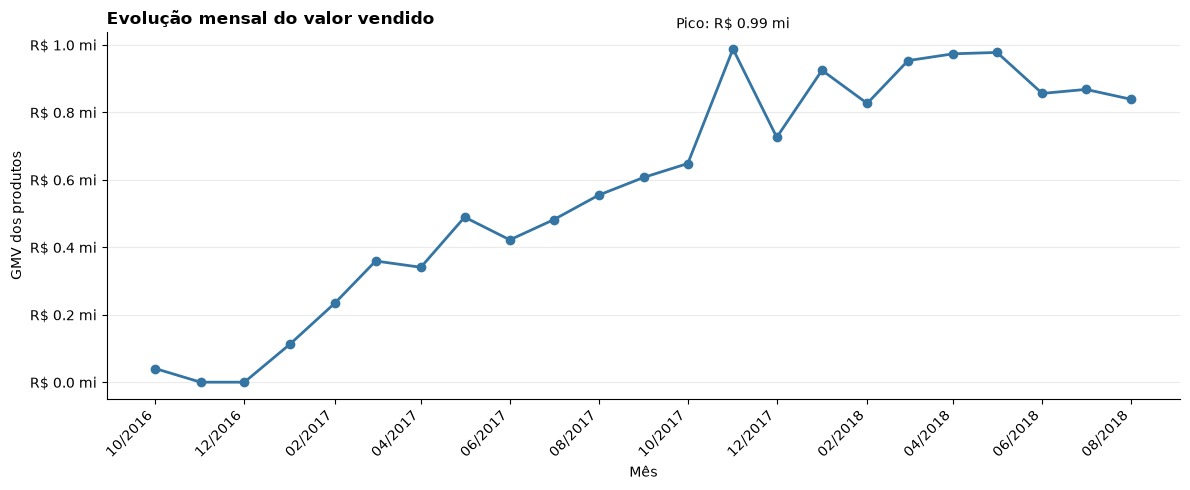

In [28]:
from matplotlib.ticker import FuncFormatter

mes_pico = gmv_mensal.loc[gmv_mensal["gmv"].idxmax()]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    gmv_mensal["mes"],
    gmv_mensal["gmv"],
    color="#3575A3",
    marker="o",
    linewidth=2
)

ax.annotate(
    f"Pico: R$ {mes_pico['gmv'] / 1_000_000:.2f} mi",
    xy=(mes_pico["mes"], mes_pico["gmv"]),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center"
)

ax.set_title(
    "Evolução mensal do valor vendido",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel("Mês")
ax.set_ylabel("GMV dos produtos")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"R$ {valor / 1_000_000:.1f} mi")
)

ax.set_xticks(gmv_mensal["mes"][::2])
ax.set_xticklabels(
    gmv_mensal["mes"][::2].dt.strftime("%m/%Y"),
    rotation=45,
    ha="right"
)

ax.grid(axis="y", alpha=0.25)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretação

O valor mensal vendido apresentou forte crescimento ao longo de 2017, acompanhando a expansão do volume de pedidos. O maior GMV ocorreu em novembro de 2017, com aproximadamente R$ 0,99 milhão em produtos vendidos.

Durante 2018, o GMV permaneceu em um patamar elevado, geralmente entre R$ 0,83 milhão e R$ 0,98 milhão por mês. O resultado mostra crescimento expressivo em relação ao início do período, seguido por relativa estabilização das vendas.

### 8.3 Categorias com maior valor vendido

Nesta etapa, os itens entregues serão associados aos produtos e à tradução das categorias. O objetivo é identificar quais categorias apresentam os maiores valores vendidos.

In [29]:
itens_com_categoria = (
    itens_entregues
    .merge(
        produtos[["product_id", "product_category_name"]],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        categorias_traducao,
        on="product_category_name",
        how="left",
        validate="many_to_one"
    )
)

itens_com_categoria["categoria"] = (
    itens_com_categoria["product_category_name_english"]
    .fillna(itens_com_categoria["product_category_name"])
    .fillna("sem_categoria")
    .str.replace("_", " ", regex=False)
    .str.title()
)

top_categorias = (
    itens_com_categoria
    .groupby("categoria", as_index=False)
    .agg(
        gmv=("price", "sum"),
        quantidade_itens=("order_item_id", "count"),
        quantidade_pedidos=("order_id", "nunique")
    )
    .sort_values("gmv", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_categorias

,categoria,gmv,quantidade_itens,quantidade_pedidos
0,Health Beauty,1233131.72,9465,8647
1,Watches Gifts,1166176.98,5859,5495
2,Bed Bath Table,1023434.76,10953,9272
3,Sports Leisure,954852.55,8431,7530
4,Computers Accessories,888724.61,7644,6530
5,Furniture Decor,711927.69,8160,6307
6,Housewares,615628.69,6795,5743
7,Cool Stuff,610204.10,3718,3559
8,Auto,578966.65,4140,3810
9,Toys,471286.48,4030,3804


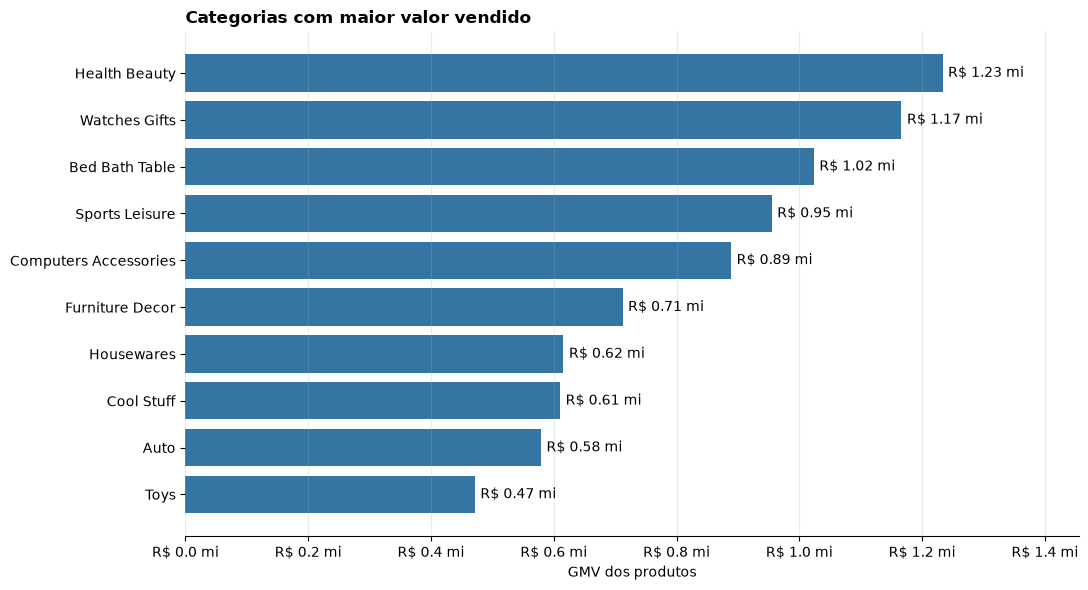

In [30]:
categorias_grafico = top_categorias.sort_values("gmv")

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.barh(
    categorias_grafico["categoria"],
    categorias_grafico["gmv"],
    color="#3575A3"
)

ax.set_title(
    "Categorias com maior valor vendido",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel("GMV dos produtos")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"R$ {valor / 1_000_000:.1f} mi")
)

ax.bar_label(
    barras,
    labels=[
        f"R$ {valor / 1_000_000:.2f} mi"
        for valor in categorias_grafico["gmv"]
    ],
    padding=4
)

ax.grid(axis="x", alpha=0.25)

for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)

ax.set_xlim(0, categorias_grafico["gmv"].max() * 1.18)

plt.tight_layout()
plt.show()

#### Interpretação

A categoria Health Beauty apresentou o maior GMV, com aproximadamente R$ 1,23 milhão, seguida por Watches Gifts, com R$ 1,17 milhão, e Bed Bath Table, com R$ 1,02 milhão.

O ranking reúne categorias variadas, como beleza, presentes, artigos domésticos, esportes e informática. Isso indica que o valor vendido não depende exclusivamente de um único tipo de produto, embora as primeiras categorias tenham participação relevante no resultado total.

## 9. Análise dos pagamentos

### 9.1 Formas de pagamento utilizadas

Nesta etapa, serão analisadas as formas de pagamento dos pedidos entregues, incluindo a quantidade de pedidos e o valor total pago em cada modalidade.

In [31]:
pedidos_entregues_ids = (
    pedidos
    .loc[pedidos["order_status"] == "delivered", ["order_id"]]
)

pagamentos_entregues = pagamentos.merge(
    pedidos_entregues_ids,
    on="order_id",
    how="inner",
    validate="many_to_one"
)

traducao_pagamentos = {
    "credit_card": "Cartão de crédito",
    "boleto": "Boleto",
    "voucher": "Voucher",
    "debit_card": "Cartão de débito",
    "not_defined": "Não definido"
}

pagamentos_entregues["forma_pagamento"] = (
    pagamentos_entregues["payment_type"]
    .map(traducao_pagamentos)
    .fillna(pagamentos_entregues["payment_type"])
)

resumo_pagamentos = (
    pagamentos_entregues
    .groupby("forma_pagamento", as_index=False)
    .agg(
        quantidade_pedidos=("order_id", "nunique"),
        quantidade_transacoes=("payment_sequential", "count"),
        valor_total=("payment_value", "sum")
    )
    .sort_values("valor_total", ascending=False)
    .reset_index(drop=True)
)

resumo_pagamentos["percentual_valor"] = (
    resumo_pagamentos["valor_total"]
    / resumo_pagamentos["valor_total"].sum()
    * 100
).round(2)

resumo_pagamentos

,forma_pagamento,quantidade_pedidos,quantidade_transacoes,valor_total,percentual_valor
0,Cartão de crédito,74304,74586,12101094.88,78.46
1,Boleto,19191,19191,2769932.58,17.96
2,Voucher,3679,5493,343013.19,2.22
3,Cartão de débito,1485,1486,208421.12,1.35


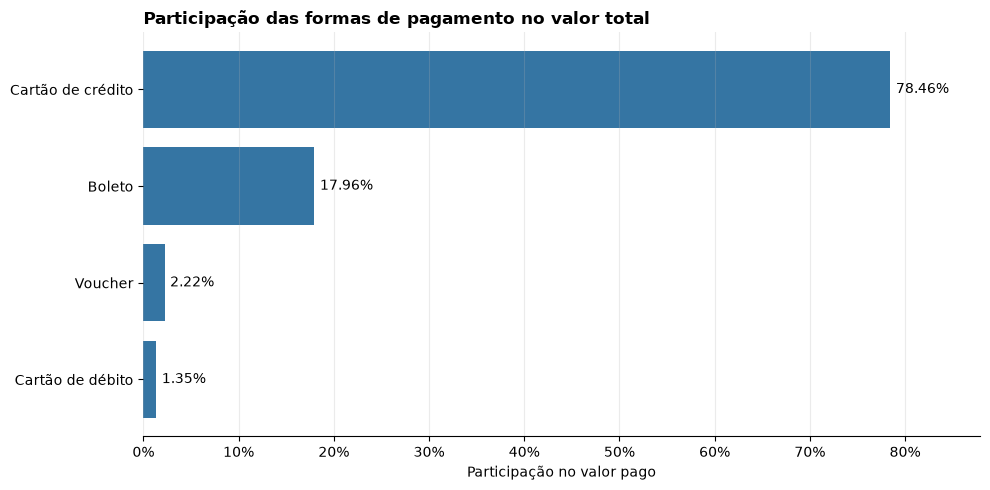

In [32]:
pagamentos_grafico = resumo_pagamentos.sort_values("percentual_valor")

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.barh(
    pagamentos_grafico["forma_pagamento"],
    pagamentos_grafico["percentual_valor"],
    color="#3575A3"
)

ax.set_title(
    "Participação das formas de pagamento no valor total",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel("Participação no valor pago")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"{valor:.0f}%")
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.2f}%"
        for valor in pagamentos_grafico["percentual_valor"]
    ],
    padding=4
)

ax.grid(axis="x", alpha=0.25)

for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)

ax.set_xlim(0, pagamentos_grafico["percentual_valor"].max() * 1.12)

plt.tight_layout()
plt.show()

#### Interpretação

O cartão de crédito foi a principal forma de pagamento, concentrando 78,46% do valor total pago nos pedidos entregues. O boleto ocupou a segunda posição, com 17,96%.

Juntas, essas duas modalidades representam 96,42% do valor pago. Voucher e cartão de débito tiveram participação reduzida, com 2,22% e 1,35%, respectivamente. Os resultados mostram forte dependência do cartão de crédito nas transações da plataforma.

### 9.2 Parcelamento no cartão de crédito

A seguir, será analisada a distribuição da quantidade de parcelas utilizada nos pagamentos com cartão de crédito.

In [34]:
pagamentos_credito = pagamentos_entregues.loc[
    (pagamentos_entregues["payment_type"] == "credit_card")
    & (pagamentos_entregues["payment_installments"] >= 1)
].copy()

pagamentos_credito["grupo_parcelas"] = (
    pagamentos_credito["payment_installments"]
    .where(pagamentos_credito["payment_installments"] <= 10, 11)
)

parcelamento = (
    pagamentos_credito
    .groupby("grupo_parcelas", as_index=False)
    .agg(
        quantidade_transacoes=("order_id", "count"),
        valor_total=("payment_value", "sum")
    )
    .sort_values("grupo_parcelas")
)

parcelamento["percentual_transacoes"] = (
    parcelamento["quantidade_transacoes"]
    / parcelamento["quantidade_transacoes"].sum()
    * 100
).round(2)

parcelamento["parcelas"] = parcelamento["grupo_parcelas"].apply(
    lambda valor: "11 ou mais" if valor == 11 else str(int(valor))
)

parcelamento[
    ["parcelas", "quantidade_transacoes", "percentual_transacoes", "valor_total"]
]

,parcelas,quantidade_transacoes,percentual_transacoes,valor_total
0,1,24759,33.20,2366960.73
1,2,12075,16.19,1528581.69
2,3,10164,13.63,1443288.05
3,4,6891,9.24,1127647.37
4,5,5095,6.83,928837.73
5,6,3804,5.10,793288.80
6,7,1563,2.10,290643.18
7,8,4136,5.55,1266801.58
8,9,618,0.83,122346.20
9,10,5150,6.90,2114267.90


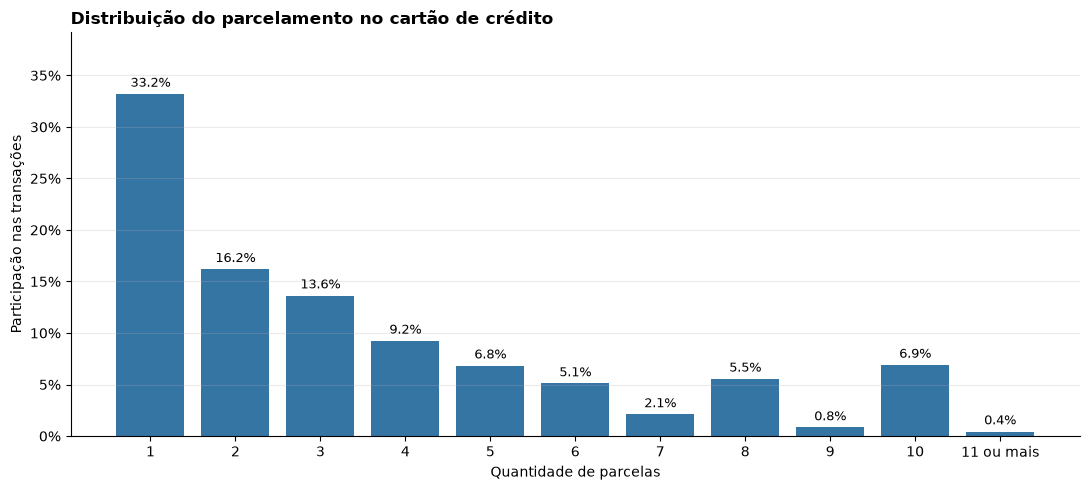

In [35]:
fig, ax = plt.subplots(figsize=(11, 5))

barras = ax.bar(
    parcelamento["parcelas"],
    parcelamento["percentual_transacoes"],
    color="#3575A3"
)

ax.set_title(
    "Distribuição do parcelamento no cartão de crédito",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel("Quantidade de parcelas")
ax.set_ylabel("Participação nas transações")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"{valor:.0f}%")
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in parcelamento["percentual_transacoes"]
    ],
    padding=3,
    fontsize=9
)

ax.grid(axis="y", alpha=0.25)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

ax.set_ylim(0, parcelamento["percentual_transacoes"].max() * 1.18)

plt.tight_layout()
plt.show()

#### Interpretação

O pagamento em uma parcela foi o mais frequente, representando 33,20% das transações com cartão de crédito. As compras realizadas entre uma e três parcelas somam 63,02% das transações.

Apesar da preferência por parcelamentos curtos, as opções de oito e dez parcelas também apresentaram participação relevante, com 5,55% e 6,90%, respectivamente. Parcelamentos acima de dez vezes foram pouco utilizados, representando apenas 0,44% das transações.